In [3]:
#df <- read.table("/nfs/turbo/umms-scjp-pank/1_HPAP/results/rna/gencode_v39_private/emptyDrops_freeze/results/pctMTusingBelowEndCliff_pctMtless30_FDR0.005/HPAP-019_metrics.csv", header = T, sep = ",")
df <- read.table("/nfs/turbo/umms-scjp-pank/0_multiomePipeline/vthihong/results/pankbase_scRNAseq/SAMN16081314_metrics.csv", header = T, sep = ",")
head(df)

,index,barcode,rna_total_reads,rna_uniquely_mapped_reads,rna_secondary_alignments,rna_supplementary_alignments,rna_umis,rna_fraction_mitochondrial,rna_gene,rna_gene_full,⋯,post_cellbender_umis,fraction_cellbender_removed,rna_percent_mitochondrial,pct_cellbender_removed,filter_cellbender_cell_probability,filter_rna_emptyDrops,filter_rna_min_umi,filter_pct_cellbender_removed,filter_rna_max_mito,pass_all_filters
,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,0,TTTCAGTAGTCATCGT,32822,29842,5842,0,17977,0.10180283,15166,17977,⋯,16689,0.07164710,10.180283,7.164710,True,True,True,True,True,True
2,1,TCATTGTCATGTGTCA,27387,25104,3318,0,11601,0.20534576,7247,11601,⋯,9854,0.15059047,20.534576,15.059047,True,True,True,True,False,False
3,2,TCCATCGGTCCAGCAC,23188,21139,2844,0,9386,0.24466626,5973,9386,⋯,7951,0.15288728,24.466626,15.288728,True,True,True,True,False,False
4,3,GTGTAACTCCACGGGT,85584,79131,10599,0,44649,0.07128685,38517,44649,⋯,43732,0.02053797,7.128685,2.053797,True,True,True,True,True,True
5,4,CAGATCATCTCTTGCG,51269,46659,7619,0,25892,0.07256906,19366,25892,⋯,24960,0.03599567,7.256906,3.599567,True,True,True,True,True,True
6,5,TAGACTGGTATGGGAC,32523,29358,4208,0,12942,0.38960420,10479,12942,⋯,11019,0.14858600,38.960420,14.858600,True,True,True,True,False,False


In [4]:
dim(df)

[1] 2515634      22

In [5]:
df <- df[df$barcode != "-",]

In [6]:
dim(df)

[1] 2515634      22

In [7]:
df <- df[order(-df$rna_umis),]
df$barcode_rank <- 1:nrow(df)

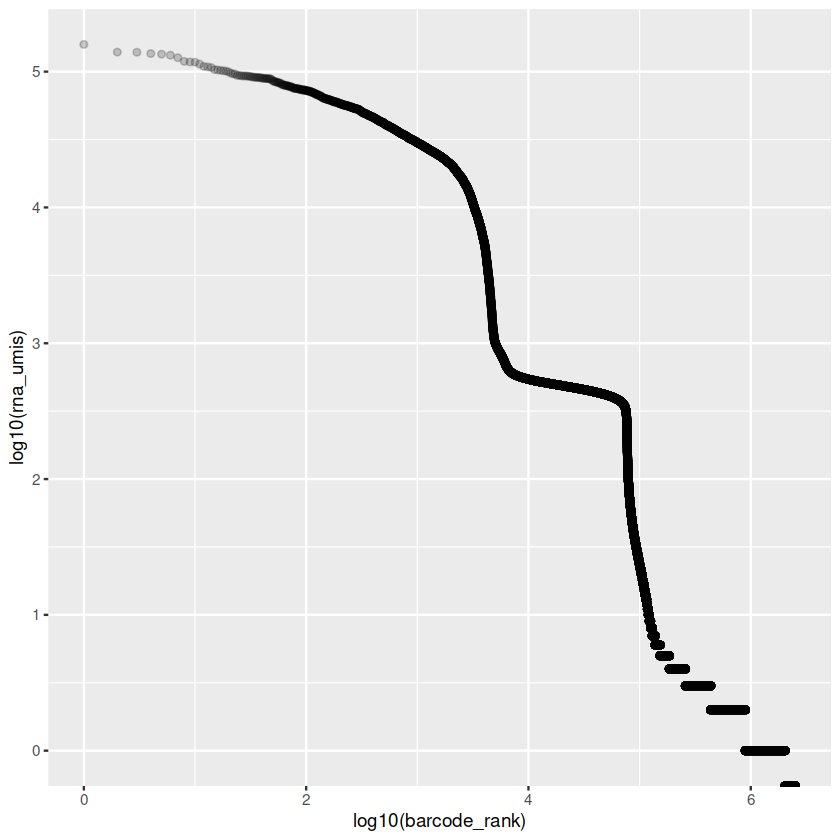

In [8]:
library("ggplot2")
ggplot(df, aes(y = log10(rna_umis), x = log10(barcode_rank))) + geom_point(alpha=0.2)

In [9]:
df <- df[df$barcode_rank < 10^5,]

In [10]:
dim(df)

[1] 99999    23

In [11]:
pass_all_filters <- df[df$pass_all_filters == "True",]
not_pass_all_filters <- df[df$pass_all_filters == "False",]

In [19]:
set.seed(1234)
shuffled_df <- pass_all_filters[sample(nrow(pass_all_filters), nrow(pass_all_filters)/30), ]
shuffled_df <- rbind(shuffled_df,
                     not_pass_all_filters[sample(nrow(not_pass_all_filters), nrow(not_pass_all_filters)/60), ]
                     )

In [20]:
dim(shuffled_df)

[1] 1717   23

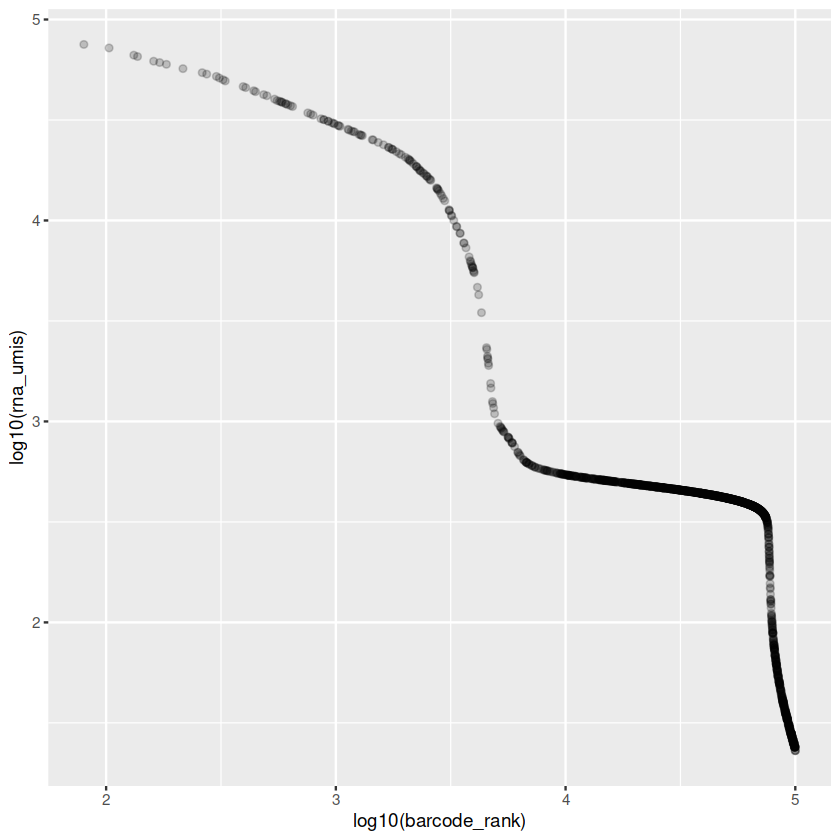

In [21]:
library("ggplot2")
ggplot(shuffled_df, aes(y = log10(rna_umis), x = log10(barcode_rank))) + geom_point(alpha=0.2)

In [22]:
dim(shuffled_df[shuffled_df$pass_all_filters == "True",])

[1] 103  23

In [23]:
write.csv(shuffled_df, "/nfs/turbo/umms-scjp-pank/vthihong/texera/20260817_tiny-workflow/data/SAMN16081314_downsampled_1.7k.csv", row.names = F, quote = F)

# subset matrix

In [24]:
library(Matrix)
dir <- "/nfs/turbo/umms-scjp-pank/vthihong/pank_scrnaseq_map/3_Prodo/results/20250408_GSE217837/starsolo/SAMN16081314-hg38/SAMN16081314-hg38.Solo.out/GeneFull_ExonOverIntron/raw/"
mat <- readMM(paste0(dir, "matrix.mtx"))
barcodes <- readLines(paste0(dir, "barcodes.tsv"))
features <- read.delim(paste0(dir, "features.tsv"), header = FALSE)

In [25]:
colnames(mat) <- barcodes
rownames(mat) <- paste0(features$V1, "_", features$V2)

keep <- read.table("/nfs/turbo/umms-scjp-pank/vthihong/texera/20260817_tiny-workflow/data/SAMN16081314_downsampled_1.7k_barcodes.tsv", header = F)
mat_sub <- mat[, colnames(mat) %in% keep$V1]

# Write back out
writeMM(mat_sub, "/nfs/turbo/umms-scjp-pank/vthihong/texera/20260817_tiny-workflow/data/SAMN16081314_downsampled_1.7k_matrix.mtx")
writeLines(colnames(mat_sub), "/nfs/turbo/umms-scjp-pank/vthihong/texera/20260817_tiny-workflow/data/SAMN16081314_downsampled_1.7k_barcodes.tsv")
writeLines(rownames(mat_sub), "/nfs/turbo/umms-scjp-pank/vthihong/texera/20260817_tiny-workflow/data/SAMN16081314_downsampled_1.7k_features.tsv")

NULL